In [1]:
%load_ext autoreload
%autoreload 2

In [63]:
from importlib import reload
import src.training
reload(src.training)

<module 'src.training' from '/home/oscar/CLP-Framework/src/training.py'>

In [64]:
from src.training import load_dataset

dataset_easy = load_dataset("datasets/E4A_1-1.data")

In [ ]:
dataset_medium = load_dataset("datasets/E4A_2-8.data")

In [ ]:
dataset_hard = load_dataset("datasets/E4A_9-64.data")

# Decoder-only model

In [14]:
from src.models.decoder_model import DecoderModel

# Parámetros del modelo
input_dim = 24     # features de las acciones
num_heads = 4
head_dim = 32
num_layers = 2
dropout = 0.1

# Crear modelo
model = DecoderModel(
    input_dim=input_dim,
    num_heads=num_heads,
    head_dim=head_dim,
    num_layers=num_layers,
    dropout_rate=dropout
)

In [15]:
from src.training import load_model

load_model(model, "decoder_easy.pth")

DecoderModel(
  (input_projection): Linear(in_features=24, out_features=128, bias=True)
  (layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (multihead_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (dense_layer): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (output_projection): Linear(in_features=128, out_features=1, bias=True)
)

In [16]:
from src.training import train

epochs = 200
datasets = [dataset_easy, dataset_medium, dataset_hard]
train_size = 16000
train_weights = [63.3, 32.1, 0]
test_size = 4000
test_weights = [63.3, 32.1, 4.6]
batch_size = 32
learning_rate = 1e-4
patience = 200
seed = 42

stats = train(model, epochs, datasets, train_size, train_weights, test_size, test_weights, batch_size, learning_rate, patience, seed)

Usando dispositivo: cpu


Epoch 1/200 - Train Loss: 1.7887, Train Accuracy: 59.23% - Val Loss: 1.6257, Val Accuracy: 61.87%
    Test Set: datasets/E4_1-1_20000.data - Val Loss: 0.6048, Val Accuracy: 91.00%
    Test Set: datasets/E4_2-8_12000.data - Val Loss: 3.6389, Val Accuracy: 4.44%
    Test Set: datasets/E4_9-64_1000.data - Val Loss: 6.2822, Val Accuracy: 0.54%
    Weighted - Val Loss: 1.8399, Val Accuracy: 59.05%
Epoch 2/200 - Train Loss: 1.5679, Train Accuracy: 59.58% - Val Loss: 1.5658, Val Accuracy: 61.22%
    Test Set: datasets/E4_1-1_20000.data - Val Loss: 0.6423, Val Accuracy: 89.53%
    Test Set: datasets/E4_2-8_12000.data - Val Loss: 3.3871, Val Accuracy: 5.37%
    Test Set: datasets/E4_9-64_1000.data - Val Loss: 6.0529, Val Accuracy: 1.09%
    Weighted - Val Loss: 1.7722, Val Accuracy: 58.45%
Epoch 3/200 - Train Loss: 1.5364, Train Accuracy: 59.57% - Val Loss: 1.5405, Val Accuracy: 61.24%
    Test Set: datasets/E4_1-1_20000.data - Val Loss: 0.7830, Val Accuracy: 88.78%
    Test Set: datasets/E4_2-

KeyboardInterrupt: 

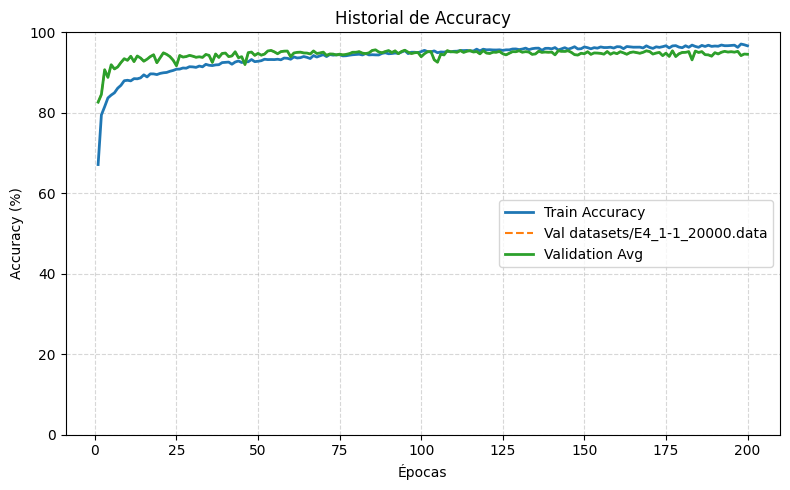

In [4]:
stats.plot()

In [5]:
from src.training import *

save_model(model, "decoder_easy.pth")

# Encoder-decoder

In [75]:
len(dataset_easy[0][1][0])

7

In [56]:
from src.models.transformer import Transformer

# Parámetros del modelo
src_dim = 3      # input encoder
tgt_dim = 18     # input decoder
num_heads = 4
head_dim = 32
num_layers = 2
dropout = 0.1

# Crear modelo
model = Transformer(
    src_dim = src_dim,
    tgt_dim = tgt_dim,
    num_heads=num_heads,
    head_dim=head_dim,
    num_layers=num_layers,
    dropout_rate=dropout
)

In [54]:
from importlib import reload
import src.training
reload(src.training)

<module 'src.training' from '/home/oscar/CLP-Framework/src/training.py'>

In [1]:
import gc
gc.collect()

0

In [70]:
from src.training import curriculum_learning

epochs = [0, 100]
train_set = [dataset_easy, dataset_medium]
train_size = 100
test_sets = [dataset_easy, dataset_medium, dataset_hard]
test_size = 50
batch_size = 1
learning_rate = 1e-4
patience = 10
seed = 42

stats = curriculum_learning(model, epochs, train_set, train_size, test_sets, test_size, batch_size, learning_rate, patience, seed)

Epoch 1/100 - Train Loss: 1.6683, Train Accuracy: 50.00% - Val Loss: 2.2651, Val Accuracy: 40.00%
    Test Set: datasets/E4F_1-1.data - Val Loss: 1.1945, Val Accuracy: 72.00%
    Test Set: datasets/E4F_2-8.data - Val Loss: 3.3357, Val Accuracy: 8.00%
    Test Set: datasets/E4F_9-64.data - Val Loss: 7.3445, Val Accuracy: 0.00%
    Average - Val Loss: 3.9582, Val Accuracy: 26.67%


KeyboardInterrupt: 

# Transformer PE

In [37]:
from src.training import load_dataset

dataset_easy = load_dataset("datasets/E4A_1-1.data")

In [38]:
dataset_medium = load_dataset("datasets/E4A_2-8.data")

In [50]:
from importlib import reload
import src.models.transformer_pe
import src.training
reload(src.training)
reload(src.models.transformer_pe)

<module 'src.models.transformer_pe' from '/home/oscar/CLP-Framework/src/models/transformer_pe.py'>

In [60]:
from src.models.transformer_pe import TransformerPE

src_dim = 5
tgt_dim = 5
d_model = 64
nhead = 4
num_layers = 2
dropout = 0.05

model = TransformerPE(src_dim, tgt_dim, d_model=d_model, nhead=nhead, num_layers=num_layers, dropout=dropout)

In [61]:
from src.training import train

epochs = 200
datasets = [dataset_easy, dataset_medium]
train_size = 1000
train_weights = [0, 32.1, 0]
test_size = 200
test_weights = [63.3, 32.1, 4.6]
batch_size = 8
learning_rate = 1e-4
patience = 200
seed = 42

stats = train(model, epochs, datasets, train_size, train_weights, test_size, test_weights, batch_size, learning_rate, patience, seed)

Usando dispositivo: cpu
Epoch 1/200 - Train Loss: 0.1000, Train Accuracy: 2.30% - Val Loss: 0.0804, Val Accuracy: 3.12%
    Test Set: datasets/E4A_1-1.data - Val Loss: 0.0802, Val Accuracy: 11.90%
    Test Set: datasets/E4A_2-8.data - Val Loss: 0.0804, Val Accuracy: 3.12%
    Weighted - Val Loss: 0.0803, Val Accuracy: 8.95%
Epoch 2/200 - Train Loss: 0.0802, Train Accuracy: 2.90% - Val Loss: 0.0799, Val Accuracy: 12.50%
    Test Set: datasets/E4A_1-1.data - Val Loss: 0.0796, Val Accuracy: 41.27%
    Test Set: datasets/E4A_2-8.data - Val Loss: 0.0799, Val Accuracy: 12.50%
    Weighted - Val Loss: 0.0797, Val Accuracy: 31.58%
Epoch 3/200 - Train Loss: 0.0798, Train Accuracy: 4.40% - Val Loss: 0.0792, Val Accuracy: 12.50%
    Test Set: datasets/E4A_1-1.data - Val Loss: 0.0786, Val Accuracy: 44.44%
    Test Set: datasets/E4A_2-8.data - Val Loss: 0.0792, Val Accuracy: 12.50%
    Weighted - Val Loss: 0.0788, Val Accuracy: 33.68%
Epoch 4/200 - Train Loss: 0.0788, Train Accuracy: 5.40% - Val Lo

KeyboardInterrupt: 